# FNQS training basics
---

A Foundation NQS (fNQS) is a single neural network $\psi(\sigma; \lambda)$ trained simultaneously over a family of Hamiltonians $H(\lambda)$ parameterised by a set of Hamiltonian parameters $\lambda$. Rather than retraining from scratch for every different Hamiltonian parameter $\lambda$, a successful optimisation run of the foundation state produces a variational state valid across the full parameter range.

NetKet foundation is a NetKet extension that introduces a small set of new 'classes' to fit this settings, while remaining relatively familiar. Moreover, NetKet foundation provides several tools to help the typical workflow of fNQS research.

This tutorial assumes familiarity with NetKet. If you are not, check out [the Ising tutorial](https://netket.readthedocs.io/en/latest/tutorials/gs-ising.html) from NetKet itself.

This tutorial covers:

1. Basics of NetKet foundation: how to set up the {class}`~netket_foundation.ParameterSpace`, the {class}`~netket_foundation.FoundationalQuantumState`, {class}`~netket_foundation.operator.ParametrizedOperator`
2. Training with the natural-gradient VMC driver {class}`~netket_foundation.VMC_NG`
3. Evaluation of energy and observables on a fine grid by means of Importance Sampling
4. Quantum Fisher information $\chi(h)$ estimate, also via importance sampling.

Importance Sampling is a tool that is necessary to make fNQS cheap. While it's trivial to use it, we recommend to give a look at some of the motivation and the diagnostics in **[Tutorial 3 – Importance Sampling](3.%20Importance%20Sampling.ipynb)**.

## System: 1D transverse-field Ising chain
---

We will be studying the 1D TFIM model, as it's super simple and runs on a laptop in seconds. The Hamiltonian is

$$
\hat H(h) = -\sum_{i=1}^L \sigma^z_i \sigma^z_{i+1} - h \sum_{i=1}^L \sigma^x_i,
\qquad \sigma^\alpha_{L+1} = \sigma^\alpha_1
$$

with $L = 10$ spins, periodic boundary conditions, and $h \in [0.75, 2.0]$. The quantum phase transition occurs at $h_c = 1$.

Like in NetKet, we will need to define the computational basis {class}`~netket.hilbert.Spin`, called _Hilbert space_ in NetKet.
But in foundation, we must also define the parameter space {class}`netket_foundation.ParameterSpace`, which behaves like a NetKet's hilbert space.
The {class}`netket_foundation.ParameterSpace` constructor takes as input the number of parameters (1 in this example), and the maximum interval, which is used when generating random parameter sets.

The other major difference from NetKet is that the Hamiltonian now depends on the parameters, so it cannot be built as usual.
Indeed, in foundation the Hamiltonian is defined as a function {code}``create_operator(parameters: jax.Array) -> NetKetOperator``.
This function must be jax-jittable, so be aware that you cannot do things like ``if params[0] == 0``. 

NetKet foundation reimplements some of NetKet's operators to make them jittable-friendly during construction. They are provided in `netket_foundation.operator`.
Notice that best performance is obtained when you build blocks of the Hamiltonians that do not have parametrised parameters, and sum/multiply them with the parameters only at the end, like the example below.

Once you have defined the {code}``create_operator`` function, you can naturally define {class}`netket_foundation.operator.ParametrizedOperator`, which you can use as usual in netket.

In [1]:
import os
os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")

from tqdm.auto import tqdm
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

import netket as nk
import netket_foundation as nkf

from netket_foundation._src.model.vit import ViTFNQS
from netket_foundation.observable import SusceptibilityObservable

∣NK⟩ Tip: To make sure your Markov chains are well-mixed, call vstate.thermalise(H) after loading a checkpoint.

In [2]:
L     = 10
hi    = nk.hilbert.Spin(0.5, L)
graph = nk.graph.Chain(L, pbc=True)

# h is a single parameter.
ps = nkf.ParameterSpace(N=1, min=0.75, max=2.0)

def create_operator(params):
    assert params.shape == (1,)
    h     = params[0]
    # For best performance, build the blocks that do not have parameters separately.
    ha_X  = sum(nkf.operator.sigmax(hi, i) for i in range(L))
    ha_ZZ = sum(
        nkf.operator.sigmaz(hi, i) @ nkf.operator.sigmaz(hi, (i + 1) % L)
        for i in range(L)
    )
    # For best performance, combine the different 'blocks' of the hamiltonian only at the end.
    return -h * ha_X - ha_ZZ

ha_p = nkf.operator.ParametrizedOperator(hi, ps, create_operator)

Mz  = sum(nkf.operator.sigmaz(hi, i) for i in range(L)) * (1.0 / L)
Mz2 = Mz @ Mz

print(f"System: 1D Ising, L={L}, h in [{ps._min}, {ps._max}]")

System: 1D Ising, L=10, h in [0.75, 2.0]


## FNQS building blocks
---

Similarly to how {class}`~netket_foundation.ParameterSpace` extends the Hilbert space and {class}`~netket_foundation.operator.ParametrizedOperator` extends the operators to foundation-style training, {class}`~netket_foundation.FoundationalQuantumState` extends the concept of {class}`netket.vqs.MCState` to fNQS. 

A {class}`~netket_foundation.FoundationalQuantumState` samples physical configurations for every  $n_\text{replicas}$ different set of parameter values. 
Each replica group of Markov chains is pinned to a different $h$.

In [3]:
import optax

# This is a sample variational ansatz
ma = ViTFNQS(
    num_layers=2,
    d_model=12,
    heads=4,
    L_eff=L // 2,
    n_coups=ps.size,
    b=2,
    complex=False,
    disorder=False,
    transl_invariant=True,
    two_dimensional=False,
)

# n_chains must be >= a multiple of n_replicas.
sa = nk.sampler.MetropolisLocal(hi, n_chains=256)
# 1024 samples, 8 replicas, means every 'replica' (i.e. every value of h) will have 128 samples.
vs = nkf.FoundationalQuantumState(sa, ma, ps, n_samples=1024, n_replicas=8, seed=1)

# parameters used for training are randomly initialised. If you want to fix them, you can set them manually as here
# where we distribute them uniformly across [0.75, 2.0].
vs.parameter_array = jnp.linspace(0.75, 2.0, vs.n_replicas).reshape(-1, 1)

print(f"Parameters: {vs.n_parameters}")
print(f"Replicas: {vs.n_replicas},  samples: {vs.n_samples} (samples per replica: {vs.n_samples//vs.n_replicas})")

Parameters: 3412
Replicas: 8,  samples: 1024 (samples per replica: 128)


## Training
---

{class}`~netket_foundation.VMC_NG` extends {class}`netket.driver.VMC_SR` to more efficiently handle the extra replica dimension. 
Arguments are the same. In this example, we take an exponentially decaying shift $\varepsilon$ which decays exponentially to prevent early convergence to a poor minimum.

In [4]:
diag_shift = optax.exponential_decay(1e-2, transition_steps=32, decay_rate=0.5)
optimizer  = optax.sgd(0.02)
gs = nkf.VMC_NG(ha_p, optimizer, variational_state=vs, diag_shift=diag_shift)

gs.run(500, show_progress=True)

online_statistics: chain_length=4, exponential moving average window: 50, decay=0.920


  0%|                                                                                                  | 0/500…

()

## Post-training evaluation
---

After training, we use `vs.get_state(h0)` to extract an {class}`~netket.vqs.MCState` at every $h_0$ without retraining. This then can be used as a usual NetKet variational state. 

```{warning}
The Markov Chains of the state obtained by `vs.get_state(h0)` are usually not thermalised. You can use `vs.thermalise(hamiltonian)` but that will be time-consuming. Not thermalising them will give likely wrong results.
```

When sweeping a fine grid, we will be spending most time converging the MCMC chains, which is time consuming.
A common way to avoid this is to converge the sampling at a small set of anchor points $h_0$, and then use importance sampling to estimate observables on different values of $h$ (see **Tutorial 3** for the theory and ESS diagnostic of importance sampling).

In [5]:
# Points where we sample and thermalise the system
h_anchors = np.linspace(0.8, 1.9, 7)

# Full MCMC at anchor points only — thermalise, then save the reference
# distribution (samples + log-probabilities) to a lightweight .npz file.
for h0 in h_anchors:
    mc = vs.get_state(jnp.array([h0]))
    mc.n_samples = 4096

    # thermalise according to the energy at the anchor point before saving
    mc.thermalise(ha_p.with_params(jnp.array([h0])), rhat_tol=1.03, verbose=False)

    nkf.vqs.samples_with_probability(mc).save(f"ising_gs_h_{h0}")

To then use the pre-prepared samples, we must then build an {class}`~netket_foundation.vqs.ISState`, an Importance Sampled state built with
{code}`vs.is_state(pars, reference=precomputed_samples)`.
This is similar to a {class}`netket.vqs.MCState`, but has fixed samples and does not resample when you call `expect`. Otherwise it will work pretty much equivalently.

In the example below, we then accumulate expectation values we estimate in an {class}`netket.utils.history.HistoryDict` object.

In [6]:
from netket.utils.history import HistoryDict

h_sweep   = np.linspace(0.75, 2.0, 51)

def nearest_anchor(h, anchors=h_anchors):
    return anchors[np.argmin(np.abs(anchors - h))]

# Load each anchor reference (a SamplesWithProb bundle) back from disk.
anchor_refs = {
    h0: nkf.expectation_value.SamplesWithProb.load(f"ising_gs_h_{h0}") for h0 in h_anchors
}

# Accumulate everything into a single HistoryDict
is_history = HistoryDict()
for i, h0 in enumerate(h_sweep):
    pars = jnp.array([h0])

    # Pair the nearest anchor's reference with the target state at `pars`.
    # ISState caches weights; both .expect() calls below reuse them.
    is_st = vs.is_state(pars, reference=anchor_refs[nearest_anchor(h0)])

    is_history.push(
        {
            "E": is_st.expect(create_operator(pars)),
            "Mz2": is_st.expect(Mz2),
            "ess": is_st.ess_fraction,
        },
        step=i,
    )

print(f"IS sweep: {len(h_sweep)} points, {len(h_anchors)} anchors.")

IS sweep: 51 points, 7 anchors.


In [7]:
# Exact diagonalisation using the same operators as training (no convention mismatch).
Mz2_sp = Mz2.to_sparse()

ed_E, ed_Mz2 = [], []
for h0 in tqdm(h_sweep):
    H_h = create_operator(jnp.array([h0]))
    E0, psi0 = nk.exact.lanczos_ed(H_h, k=1, compute_eigenvectors=True)
    psi0 = psi0.reshape(-1)
    ed_E.append(float(E0[0]))
    ed_Mz2.append(float(np.real(psi0.conj() @ (Mz2_sp @ psi0))))

ed_E   = np.array(ed_E)
ed_Mz2 = np.array(ed_Mz2)
print("ED done.")

  0%|          | 0/51 [00:00<?, ?it/s]

ED done.


And then plot the result. Notice that every time we change the importance sampling anchoring we get a slight discontinuity.

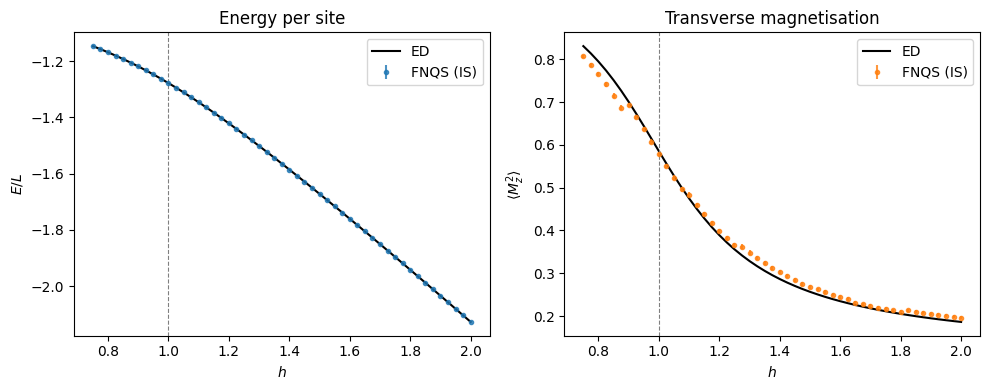

In [8]:
# Pull the recorded means and errors straight out of the HistoryDict.
is_E       = np.asarray(is_history["E"]["Mean"]).real
is_E_err   = np.asarray(is_history["E"]["Sigma"]).real
is_Mz2     = np.asarray(is_history["Mz2"]["Mean"]).real
is_Mz2_err = np.asarray(is_history["Mz2"]["Sigma"]).real

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ax = axes[0]
ax.plot(h_sweep, ed_E / L, "k-", lw=1.5, label="ED")
ax.errorbar(h_sweep, is_E / L, yerr=is_E_err / L, fmt="o", ms=3,
            color="tab:blue", label="FNQS (IS)", alpha=0.8)
ax.axvline(1.0, ls="--", color="gray", lw=0.8)
ax.set_xlabel("$h$")
ax.set_ylabel("$E / L$")
ax.set_title("Energy per site")
ax.legend()

ax = axes[1]
ax.plot(h_sweep, ed_Mz2, "k-", lw=1.5, label="ED")
ax.errorbar(h_sweep, is_Mz2, yerr=is_Mz2_err, fmt="o", ms=3,
            color="tab:orange", label="FNQS (IS)", alpha=0.8)
ax.axvline(1.0, ls="--", color="gray", lw=0.8)
ax.set_xlabel("$h$")
ax.set_ylabel(r"$\langle M_z^2 \rangle$")
ax.set_title("Transverse magnetisation")
ax.legend()

plt.tight_layout()
plt.show()

## Quantum Fisher information via IS
---

The fidelity susceptibility with respect to $h$ is

$$
\chi(h) = \mathrm{Var}_{|\psi(h)|^2}\!\left[\partial_h \log\psi(\sigma;\,h)\right]
         = \bigl\langle (\partial_h \log\psi)^2\bigr\rangle
           - \bigl\langle \partial_h \log\psi\bigr\rangle^2.
$$
It peaks at the quantum phase transition ($h_c = 1$ in the thermodynamic limit) and measures how rapidly the ground-state manifold curves as $h$ varies.

This can be computed by defining the 'observable' object {class}`netket_foundation.observable.SusceptibilityObservable`, and then calling `.expect` on an MCState derived from a foundation quantum state.
It can also be computed via IS: reuse the nearest anchor's samples with IS weights, then evaluate the weighted variance of $\partial_h\log\psi$ using `jax.jacfwd`.

In [9]:
# The susceptibility estimator returns a (StatsBatch-derived) matrix result, so
# we can push it straight into a HistoryDict just like the scalar observables.
qfi_history = HistoryDict()
for i, h0 in enumerate(h_sweep):
    pars   = jnp.array([h0])
    is_st  = vs.is_state(pars, reference=anchor_refs[nearest_anchor(h0)])
    qfi_history.push({"chi": is_st.expect(SusceptibilityObservable(hi))}, step=i)

# chi.Mean has shape (n_steps, n_params, n_params); here n_params == 1.
qfi_vals = np.asarray(qfi_history["chi"]["Mean"]).real[:, 0, 0]
print(f"QFI sweep done. Peak at h = {h_sweep[np.argmax(qfi_vals)]:.2f}")

QFI sweep done. Peak at h = 0.88


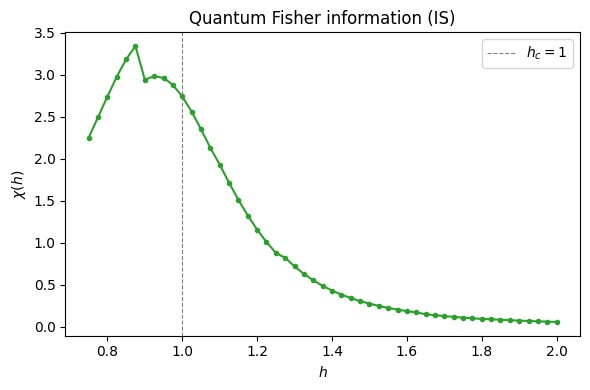

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(h_sweep, qfi_vals, "-o", ms=3, color="tab:green")
ax.axvline(1.0, ls="--", color="gray", lw=0.8, label="$h_c = 1$")
ax.set_xlabel("$h$")
ax.set_ylabel(r"$\chi(h)$")
ax.set_title("Quantum Fisher information (IS)")
ax.legend()

plt.tight_layout()
plt.show()